In [ ]:
!pip install optuna

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input, Activation, concatenate, Bidirectional, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import optimizers
from tensorflow.keras import backend as K
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import os

In [ ]:
# check if file exists
if not os.path.exists('../data_created/21-Jul-2023-00-54-56-INS_GPS_function_imu_train.csv'):
    !wget https://raw.githubusercontent.com/alibaniasad1999/otter-USV/refs/heads/main/data_created/21-Jul-2023-00-54-56-INS_GPS_function_imu_train.csv
    imu = pd.read_csv('21-Jul-2023-00-54-56-INS_GPS_function_imu_train.csv', header=None)
else:
    imu = pd.read_csv('../data_created/21-Jul-2023-00-54-56-INS_GPS_function_imu_train.csv', header=None)
if not os.path.exists('../data_created/21-Jul-2023-00-54-54-INS_GPS_function_true_data.csv'):
    !wget https://raw.githubusercontent.com/alibaniasad1999/otter-USV/refs/heads/main/data_created/21-Jul-2023-00-54-54-INS_GPS_function_true_data.csv
    true_data = pd.read_csv('21-Jul-2023-00-54-54-INS_GPS_function_true_data.csv', header=None)
else:
    true_data = pd.read_csv('../data_created/21-Jul-2023-00-54-54-INS_GPS_function_true_data.csv', header=None)
if not os.path.exists('../data_created/21-Jul-2023-00-54-51-INS_GPS_function_estimate_data.csv'):
    !wget https://raw.githubusercontent.com/alibaniasad1999/otter-USV/refs/heads/main/data_created/21-Jul-2023-00-54-51-INS_GPS_function_estimate_data.csv
    estimated_data = pd.read_csv('21-Jul-2023-00-54-51-INS_GPS_function_estimate_data.csv', header=None)
else:
    estimated_data = pd.read_csv('../data_created/21-Jul-2023-00-54-51-INS_GPS_function_estimate_data.csv', header=None)

--2025-01-29 12:23:45--  https://raw.githubusercontent.com/alibaniasad1999/otter-USV/refs/heads/main/data_created/21-Jul-2023-00-54-56-INS_GPS_function_imu_train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3189040 (3.0M) [text/plain]
Saving to: ‘21-Jul-2023-00-54-56-INS_GPS_function_imu_train.csv.4’

21-Jul-2023-00-54-5 100%[===================>]   3.04M  --.-KB/s    in 0.01s   

2025-01-29 12:23:46 (254 MB/s) - ‘21-Jul-2023-00-54-56-INS_GPS_function_imu_train.csv.4’ saved [3189040/3189040]

--2025-01-29 12:23:46--  https://raw.githubusercontent.com/alibaniasad1999/otter-USV/refs/heads/main/data_created/21-Jul-2023-00-54-54-INS_GPS_function_true_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.1

In [ ]:
# plt.plot(estimated_data)
true_data = true_data.to_numpy()
estimated_data = estimated_data.to_numpy()
estimated_data = estimated_data[0:100000, :]

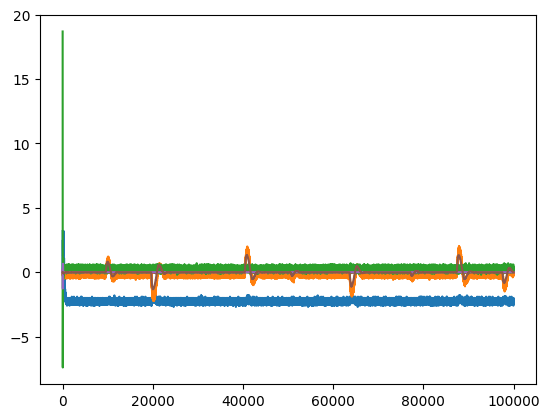

In [ ]:
# imu = imu.to_numpy()
plt.plot((imu+np.array([0, 0, 9.8, 0, 0, 0]))*10)

In [ ]:
x_train = (imu+np.array([0, 0, 9.8, 0, 0, 0]))*10
x_train.to_numpy()
x_train.shape

(100000, 6)

In [ ]:
y_train = 100*(estimated_data)
y_train.shape

(100000, 9)

In [ ]:
# function make x train data with 10 sequence
def make_x_train(x_train, x_train1, sequence_length):
    x_result = []
    x_result1 = []
    for index in range(len(x_train) - sequence_length):
        x_result.append(x_train[index: index + sequence_length])
        x_result1.append(x_train1[index])
    return np.array(x_result), np.array(x_result1)

In [ ]:
x_train, x_train1 = make_x_train(x_train, y_train, 10)
x_train.shape

(99990, 10, 6)

In [ ]:
y_train = 100*(estimated_data)
y_train.shape
y_train = y_train[10:]
y_train.shape

(99990, 9)

In [ ]:
y_train.shape[1]

9

In [ ]:
# change datat to tensor #
x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)
x_train1 = tf.convert_to_tensor(x_train1, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)

In [ ]:
# select device
if tf.test.gpu_device_name():
    print('GPU found')
    device = '/device:GPU:0'
else:
    print("No GPU found")
    device = '/device:CPU:0'

GPU found


In [ ]:
# define the model building function
def build_model(trial, x_train, x_train1, y_train):
    input_1 = Input(shape=(x_train.shape[1], x_train.shape[2]))
    input_2 = Input(shape=(x_train1.shape[1],1))

    # Number of LSTM layers in each branch
    n_layers_1 = trial.suggest_int("n_layers_1", 1, 3)
    n_layers_2 = trial.suggest_int("n_layers_2", 1, 3)

    # LSTM for first input
    x1 = input_1
    for i in range(n_layers_1):
        units = trial.suggest_categorical(f"lstm1_units_{i}", [8, 16, 32, 64])
        x1 = LSTM(units, return_sequences=True)(x1)

    # LSTM for second input
    x2 = input_2
    for i in range(n_layers_2):
        units = trial.suggest_categorical(f"lstm2_units_{i}", [8, 16, 32, 64])
        x2 = LSTM(units, return_sequences=True)(x2)

    # Flatten before concatenation to ensure shapes match
    x1 = Flatten()(x1)
    x2 = Flatten()(x2)
    merged = concatenate([x1, x2])

    # **Number of Dense layers**
    n_dense_layers = trial.suggest_int("n_dense_layers", 1, 3)

    for i in range(n_dense_layers):
        dense_units = trial.suggest_categorical(f"dense_units_{i}", [8, 16, 32, 64])
        merged = Dense(dense_units, activation='linear', kernel_regularizer=regularizers.l2(0.01))(merged)

    # Output layer
    output = Dense(y_train.shape[1], activation='linear')(merged)

    model = Model(inputs=[input_1, input_2], outputs=output)


    # Optimizer tuning
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    model.compile(optimizer=Adam(learning_rate=lr), loss="mse", metrics=["mae"])

    return model


In [ ]:
# Objective function for Optuna
def objective(trial):
    # Clear clutter from previous TensorFlow graphs.
    K.clear_session()

    # Build the model
    model = build_model(trial, x_train, x_train1, y_train)

    model.summary()

    # early stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1)

    # Fit the model
    with tf.device(device):
        history = model.fit([x_train, x_train1], y_train, epochs=100, batch_size=128, validation_split=0.2, callbacks=[early_stop])

    # Evaluate the model
    val_loss = min(history.history["val_loss"])  # **Use best validation loss**

    return val_loss


In [ ]:
# Create a study object and optimize the objective function.
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

[I 2025-01-29 12:29:45,071] A new study created in memory with name: no-name-ca8be902-8356-4448-a043-5823715d9604
<ipython-input-85-9c455270d441>:41: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 10, 6)          │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 9, 1)           │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ (None, 10, 16)         │          1,472 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ (None, 9, 64)          │         16,896 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten (Flatten)         │ (None, 160)            │              0 │ lstm[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ flatten_1 (Flatten)       │ (None, 576)            │              0 │ lstm_1[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 736)            │              0 │ flatten[0][0],         │
│                           │                        │                │ flatten_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 8)              │          5,896 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 64)             │            576 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 9)              │            585 │ dense_1[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 25,425 (99.32 KB)

 Trainable params: 25,425 (99.32 KB)

...

 Total params: 82,953 (324.04 KB)

 Trainable params: 82,953 (324.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 464.7704 - mae: 8.2941 - val_loss: 3.2668 - val_mae: 0.6400
Epoch 2/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 2.2703 - mae: 0.4668 - val_loss: 2.8308 - val_mae: 0.6498
Epoch 3/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 1.8686 - mae: 0.4225 - val_loss: 2.0573 - val_mae: 0.5114
Epoch 4/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 1.5726 - mae: 0.3994 - val_loss: 1.8299 - val_mae: 0.4819
Epoch 5/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 1.3492 - mae: 0.3614 - val_loss: 1.9020 - val_mae: 0.4886
Epoch 6/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 1.1948 - mae: 0.3292 - val_loss: 1.4781 - val_mae: 0.4468
Epoch 7/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 1.0904 - mae: 0.3029 - val_loss: 1.6742 - val_mae: 0.4327
Epoch 8/100
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 1.0047 - mae: 0.2936 - val_loss: 1.3339 - val_mae: 0.4194
Epoch 9/100
625/625 ━━━━━━━━━━━━━

[I 2025-01-29 13:52:37,071] Trial 9 finished with value: 0.7156029939651489 and parameters: {'n_layers_1': 2, 'n_layers_2': 2, 'lstm1_units_0': 64, 'lstm1_units_1': 64, 'lstm2_units_0': 64, 'lstm2_units_1': 8, 'n_dense_layers': 3, 'dense_units_0': 16, 'dense_units_1': 16, 'dense_units_2': 32, 'lr': 0.0013962230949070905}. Best is trial 7 with value: 0.30159005522727966.


In [ ]:
print(study)

In [ ]:
!pip install joblib
import joblib

# Let's say I want to save study to savepath + "xgb_optuna_study_batch.pkl"

joblib.dump(study, "xgb_optuna_study_batch.pkl")   # save study

['xgb_optuna_study_batch.pkl']

In [ ]:
# You can use Matplotlib instead of Plotly for visualization by simply replacing `optuna.visualization` with
# `optuna.visualization.matplotlib` in the following examples.
from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_rank
from optuna.visualization import plot_slice
from optuna.visualization import plot_timeline

In [ ]:
plot_optimization_history(study)

In [ ]:
plot_intermediate_values(study)

[W 2025-01-29 14:07:30,883] You need to set up the pruning feature to utilize `plot_intermediate_values()`


In [ ]:
plot_parallel_coordinate(study)

[W 2025-01-29 13:59:31,038] Your study has only completed trials with missing parameters.


In [ ]:
plot_parallel_coordinate(study, params=["n_layers_1", "n_layers_2"])

In [ ]:
plot_contour(study)

[W 2025-01-29 14:01:48,580] Param lstm1_units_2 unique value length is less than 2.
[W 2025-01-29 14:01:48,584] Param lstm1_units_2 unique value length is less than 2.
[W 2025-01-29 14:01:48,586] Param lstm1_units_2 unique value length is less than 2.
[W 2025-01-29 14:01:48,590] Param lstm1_units_2 unique value length is less than 2.
[W 2025-01-29 14:01:48,592] Param lstm1_units_2 unique value length is less than 2.
[W 2025-01-29 14:01:48,596] Param lstm1_units_2 unique value length is less than 2.
[W 2025-01-29 14:01:48,597] Param lstm1_units_2 unique value length is less than 2.
[W 2025-01-29 14:01:48,599] Param lstm1_units_2 unique value length is less than 2.
[W 2025-01-29 14:01:48,600] Param lstm1_units_2 unique value length is less than 2.
[W 2025-01-29 14:01:48,601] Param lstm1_units_2 unique value length is less than 2.
[W 2025-01-29 14:01:48,602] Param lstm1_units_2 unique value length is less than 2.
[W 2025-01-29 14:01:48,603] Param lstm1_units_2 unique value length is less 

In [ ]:
fig = plot_intermediate_values(study)

fig.update_layout(
    title="Hyperparameter optimization for FashionMNIST classification",
    xaxis_title="Epoch",
    yaxis_title="Validation Accuracy",
)

[W 2025-01-29 14:02:35,616] You need to set up the pruning feature to utilize `plot_intermediate_values()`


In [ ]:
print(study)

In [ ]:
import pandas as pd

In [ ]:
study = optuna.create_study(study_name=study, load_if_exists=True)
df = study.trials_dataframe(attrs=("number", "value", "params", "state"))


[I 2025-01-29 14:07:45,061] A new study created in memory with name: <optuna.study.study.Study object at 0x78037d2f0910>


In [ ]:
print("Best params: ", study.best_params)
print("Best value: ", study.best_value)
print("Best Trial: ", study.best_trial)
print("Trials: ", study.trials)

ValueError: No trials are completed yet.

In [ ]:
print(df)

Empty DataFrame
Columns: []
Index: []


In [ ]:
study.trials_dataframe()

""


In [ ]:
# Reload study
study = joblib.load('xgb_optuna_study_batch.pkl')
print(study.trials_dataframe())  # Should now contain results

   number     value             datetime_start          datetime_complete  \
0       0  0.342943 2025-01-29 12:29:45.073076 2025-01-29 12:35:19.011668   
1       1  1.012329 2025-01-29 12:35:19.013504 2025-01-29 12:42:25.459388   
2       2  0.389864 2025-01-29 12:42:25.462310 2025-01-29 12:50:18.167806   
3       3  0.480385 2025-01-29 12:50:18.171311 2025-01-29 13:05:42.850790   
4       4  1.479015 2025-01-29 13:05:42.852832 2025-01-29 13:13:51.677198   
5       5  1.182103 2025-01-29 13:13:51.680872 2025-01-29 13:19:51.649836   
6       6  0.422287 2025-01-29 13:19:51.652511 2025-01-29 13:25:48.367140   
7       7  0.301590 2025-01-29 13:25:48.372200 2025-01-29 13:37:00.555519   
8       8  0.584570 2025-01-29 13:37:00.558716 2025-01-29 13:45:33.519876   
9       9  0.715603 2025-01-29 13:45:33.521951 2025-01-29 13:52:37.070496   

                duration  params_dense_units_0  params_dense_units_1  \
0 0 days 00:05:33.938592                     8                  64.0   
1 0 days